In [1]:
from sentiment_analysis.loader import get_kaggle_data

df = get_kaggle_data()
print(df.head(10))

/Users/bengould/Documents/Projects/sentiment-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dataframe arranged successfully
  sentiment                                           sentence
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...
5  positive  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
6  positive  For the last quarter of 2010 , Componenta 's n...
7  positive  In the third quarter of 2010 , net sales incre...
8  positive  Operating profit rose to EUR 13.1 mn from EUR ...
9  positive  Operating profit totalled EUR 21.1 mn , up fro...


In [2]:
df['word_number'] = df.transform({'sentence': lambda x: len(x.split())})

In [3]:
df

,sentiment,sentence,word_number
0,neutral,"According to Gran , the company has no plans t...",25
1,neutral,Technopolis plans to develop in stages an area...,31
2,negative,The international electronic industry company ...,36
3,positive,With the new production plant the company woul...,33
4,positive,According to the company 's updated strategy f...,41
...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,26
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,30
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,23
4844,negative,Net sales of the Paper segment decreased to EU...,44


In [4]:
df['unique_word_number'] = df.transform({'sentence': lambda x: len(set(x.split()))})

In [5]:
df

,sentiment,sentence,word_number,unique_word_number
0,neutral,"According to Gran , the company has no plans t...",25,19
1,neutral,Technopolis plans to develop in stages an area...,31,28
2,negative,The international electronic industry company ...,36,31
3,positive,With the new production plant the company woul...,33,24
4,positive,According to the company 's updated strategy f...,41,32
...,...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,26,25
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,30,22
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,23,19
4844,negative,Net sales of the Paper segment decreased to EU...,44,29


In [6]:
len_df = len(df)
num_pos = len(df[df['sentiment'] == 'positive'])
num_neg = len(df[df['sentiment'] == 'negative'])
num_neut = len(df[df['sentiment'] == 'neutral'])

print(f"Total number of headlines: {len_df}")
print(f"Fraction of positive headlines: {num_pos/len_df*100}%")
print(f"Fraction of negative headlines: {num_neg/len_df*100}%")
print(f"Fraction of neutral headlines: {num_neut/len_df*100}%")

Total number of headlines: 4846
Fraction of positive headlines: 28.126289723483282%
Fraction of negative headlines: 12.463887742468014%
Fraction of neutral headlines: 59.40982253404869%


In [16]:
avg_len_pos = df[df['sentiment'] == 'positive']['word_number'].median()
avg_len_neg = df[df['sentiment'] == 'negative']['word_number'].median()
avg_len_neut = df[df['sentiment'] == 'neutral']['word_number'].median()

print(f"Median word number for positive headlines: {avg_len_pos}")
print(f"Median word number for negative headlines: {avg_len_neg}")
print(f"Median word number for neutral headlines: {avg_len_neut}")

Median word number for positive headlines: 23.0
Median word number for negative headlines: 22.0
Median word number for neutral headlines: 21.0


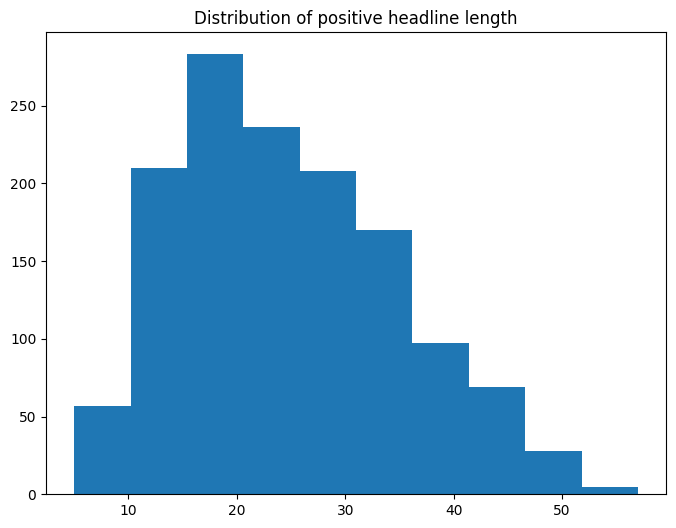

In [13]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8,6))
plt.hist(df[df['sentiment'] == 'positive']['word_number'].values)
plt.title('Distribution of positive headline length')
plt.show()

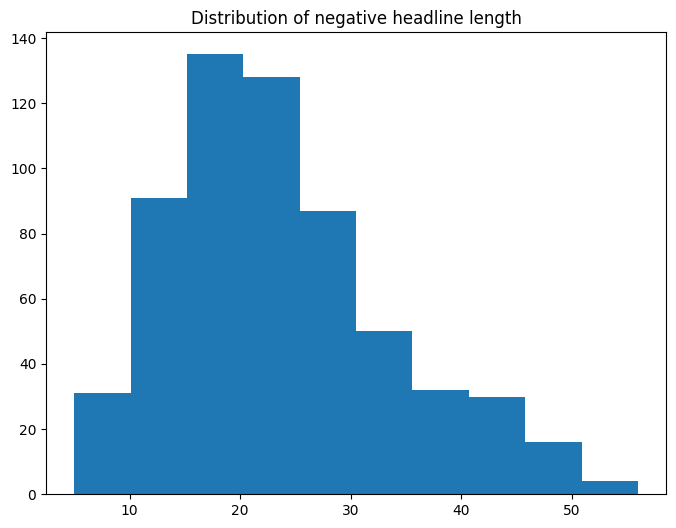

In [14]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8,6))
plt.hist(df[df['sentiment'] == 'negative']['word_number'].values)
plt.title('Distribution of negative headline length')
plt.show()

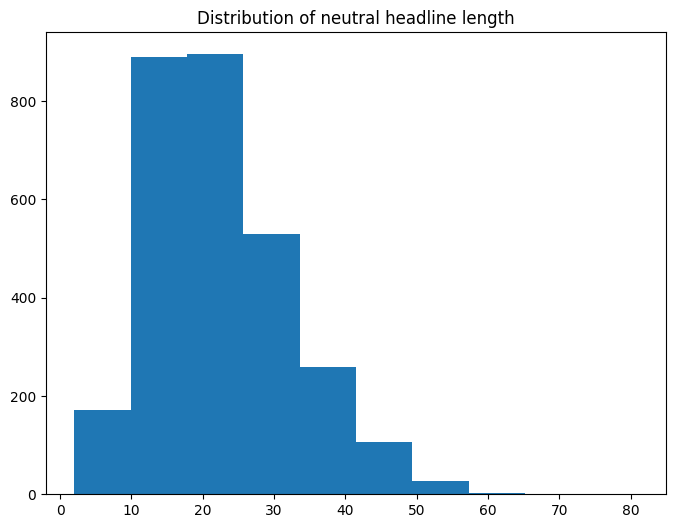

In [15]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8,6))
plt.hist(df[df['sentiment'] == 'neutral']['word_number'].values)
plt.title('Distribution of neutral headline length')
plt.show()

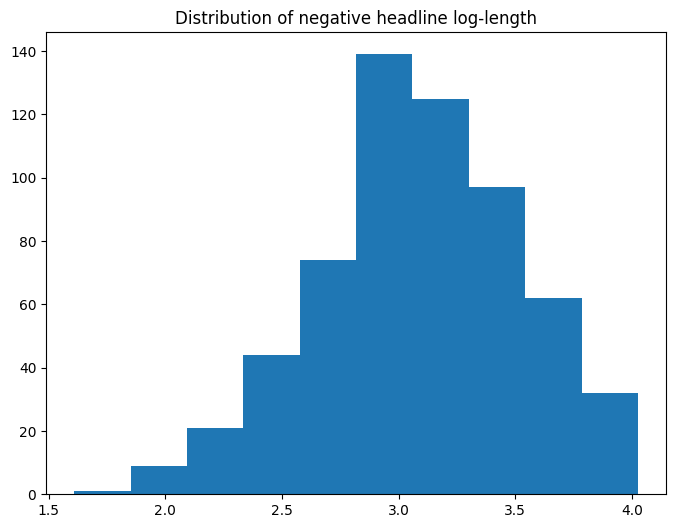

In [21]:
pos_skew = df[df['sentiment'] == 'positive']['word_number'].skew()
neg_skew = df[df['sentiment'] == 'negative']['word_number'].skew()
neutral_skew = df[df['sentiment'] == 'neutral']['word_number'].skew()

print(f"pos skew: {pos_skew}")
print(f"neg skew: {neg_skew}")
print(f"neutral skew: {neutral_skew}")

pos skew: 0.5529407051283628
neg skew: 0.7490109601658628
neutral skew: 0.7893073035716163


In [37]:
from sklearn.model_selection import train_test_split

X = df['sentence']
y = df['sentiment']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=.15, stratify=df['sentiment'])

X_new = df[df.index.isin(X_train_val.index)]

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=.15/.85, stratify=X_new['sentiment'])

In [39]:
df_train = df[df.index.isin(X_train.index)]
df_val = df[df.index.isin(X_val.index)]
df_test = df[df.index.isin(X_test.index)]

print(f"The number of rows to start was {len(df)}")
print(f"The number of training rows is {len(df_train)} which is {len(df_train)/len(df)*100}% of the total")
print(f"The number of validation rows is {len(df_val)} which is {len(df_val)/len(df)*100}% of the total")

The number of rows to start was 4846
The number of training rows is 3392 which is 69.99587288485348% of the total
The number of validation rows is 727 which is 15.002063557573257% of the total


In [41]:


print(f"The number of rows to start was {len(df)}")
print(f"The number of training target rows is {len(y_train)} which is {len(y_train)/len(df)*100:.2f}% of the total")
print(f"The number of validation target rows is {len(y_val)} which is {len(y_val)/len(df)*100:.2f}% of the total")

The number of rows to start was 4846
The number of training target rows is 3392 which is 70.00% of the total
The number of validation target rows is 727 which is 15.00% of the total
